# Интерпретация

In [1]:
%pip install -r ../requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
import os 
from dotenv import load_dotenv

load_dotenv()
data_path = os.getenv('interpritation') + '/data.csv'

data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


In [5]:
%pip install ydata-profiling -q

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title="Quick Analysis")
profile.to_file("report.html") 

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 83/83 [00:01<00:00, 64.61it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = 'price_target'

df = data.copy()
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = ['region_name_cat', 'district_cat', 'location_depth', 
            'location_car_rental_cnt', 'location_bus_station_cnt']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown').astype(str)

rooms_mapping = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}
df['rooms_4'] = df['rooms_4'].map(rooms_mapping).fillna(0)

district_means = df.groupby('district_cat')[target_col].mean()
df['district_target_enc'] = df['district_cat'].map(district_means)

cols_to_ohe = ['region_name_cat', 'location_depth', 'location_car_rental_cnt']
df_final = pd.get_dummies(df, columns=cols_to_ohe, drop_first=True)

df_final = df_final.drop(columns=['district_cat', 'agreement_date'], errors='ignore')

X = df_final.drop(columns=[target_col])
y = df_final[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Форма данных после кодирования: {X_train_scaled.shape}")
print("Топ признаков (первые 5):", X_train_scaled.columns[:5].tolist())

Форма данных после кодирования: (23922, 82)
Топ признаков (первые 5): ['corpus_cat', 'developer_cat', 'floor', 'square', 'rooms_4']


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [4]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler

X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

mm_scaler = MinMaxScaler()
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=X_train.columns)
X_test_mm = pd.DataFrame(mm_scaler.transform(X_test), columns=X_test.columns)

data_variants = {
    "Original": (X_train_orig, X_test_orig),
    "Standard": (X_train_scaled, X_test_scaled),
    "MinMax": (X_train_mm, X_test_mm)
}

models_dict = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(random_state=42, max_iter=5000),
    "GradientBoosting": GradientBoostingRegressor(max_depth=5, random_state=42)
}

results = []

for scaler_name, (X_tr, X_te) in data_variants.items():
    for model_name, model in models_dict.items():
        model.fit(X_tr, y_train)
        preds = model.predict(X_te)
        
        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_test, preds)
        
        results.append({
            "Model": model_name,
            "Scaler": scaler_name,
            "MSE": mse,
            "RMSE": rmse,
            "MAPE": mape
        })

results_df = pd.DataFrame(results)
print(results_df.sort_values("MAPE"))

              Model    Scaler           MSE         RMSE      MAPE
5  GradientBoosting  Standard  3.228951e+06  1796.928230  0.041030
2  GradientBoosting  Original  3.231259e+06  1797.570187  0.041037
8  GradientBoosting    MinMax  3.248327e+06  1802.311450  0.041486
7             Lasso    MinMax  9.792189e+06  3129.247311  0.078277
3  LinearRegression  Standard  9.786061e+06  3128.268045  0.078711
0  LinearRegression  Original  9.786061e+06  3128.268045  0.078711
6  LinearRegression    MinMax  9.785114e+06  3128.116722  0.078723
4             Lasso  Standard  9.845153e+06  3137.698739  0.078936
1             Lasso  Original  9.835121e+06  3136.099591  0.079397


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [5]:
results_1_1 = []

for scaler_name in ["Standard", "MinMax"]:
    X_tr, X_te = data_variants[scaler_name]
    model = Lasso(random_state=42, max_iter=5000)
    model.fit(X_tr, y_train)
    
    importance = pd.Series(np.abs(model.coef_), index=X_train.columns)
    top_5 = importance.sort_values(ascending=False).head(5)
    
    for feat, val in top_5.items():
        results_1_1.append({"Scaler": scaler_name, "Feature": feat, "Importance": val})

df_importance = pd.DataFrame(results_1_1)
print(df_importance.pivot(index='Feature', columns='Scaler', values='Importance'))

Scaler                                    MinMax     Standard
Feature                                                      
district_target_enc                 76896.342380  7643.293658
location_fuel_w_mean_distance                NaN  1612.062867
location_logs_count_mean            11195.233643  1838.365376
location_motel_cnt                  13675.330094          NaN
location_parking_cnt                 9800.464997  1654.553872
location_shop_alco_w_mean_distance           NaN  1387.583481
square                               9948.033764          NaN


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

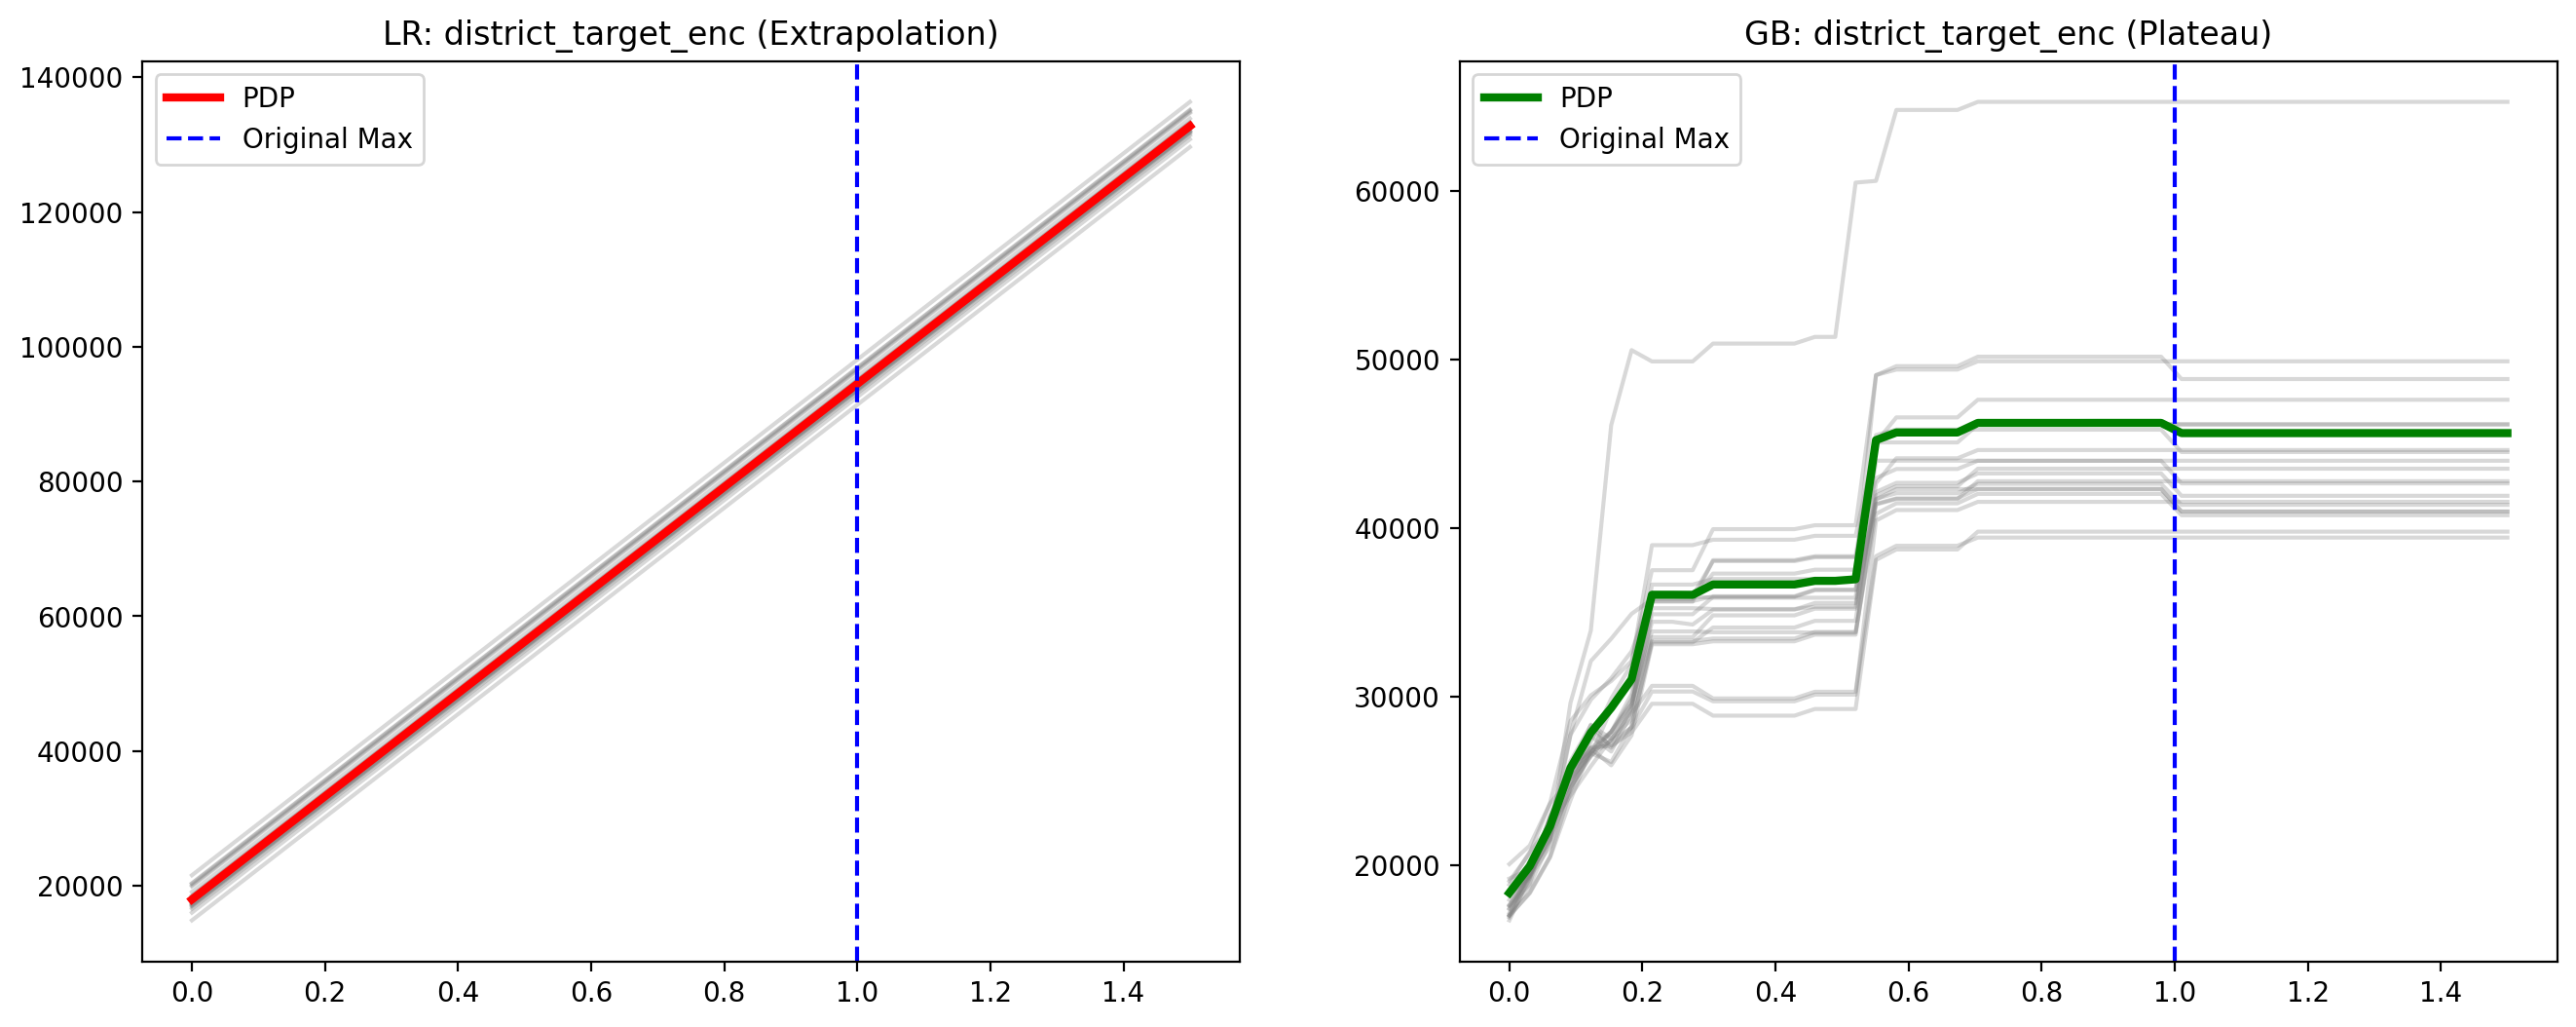

In [ ]:
import matplotlib.pyplot as plt

feature_1 = 'district_target_enc' 
X_tr_mm, X_te_mm = data_variants["MinMax"]

lr_model = LinearRegression().fit(X_tr_mm, y_train)
gb_model = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_tr_mm, y_train)

def manual_ice_pdp(model, X_data, feature_name, grid_points):
    ice_lines = []
    X_temp = X_data.copy()
    for val in grid_points:
        X_temp[feature_name] = val
        ice_lines.append(model.predict(X_temp))
    ice_lines = np.array(ice_lines).T
    return ice_lines, ice_lines.mean(axis=0)

grid_1 = np.linspace(0, 1.5, 50) 
X_subset = X_te_mm.iloc[:100]

ice_lr, pdp_lr = manual_ice_pdp(lr_model, X_subset, feature_1, grid_1)
ice_gb, pdp_gb = manual_ice_pdp(gb_model, X_subset, feature_1, grid_1)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i in range(20):
    ax[0].plot(grid_1, ice_lr[i], color='gray', alpha=0.3)
ax[0].plot(grid_1, pdp_lr, color='red', linewidth=3, label='PDP')
ax[0].axvline(1.0, color='blue', linestyle='--', label='Original Max')
ax[0].set_title(f'LR: {feature_1} (Extrapolation)')
ax[0].legend()

for i in range(20):
    ax[1].plot(grid_1, ice_gb[i], color='gray', alpha=0.3)
ax[1].plot(grid_1, pdp_gb, color='green', linewidth=3, label='PDP')
ax[1].axvline(1.0, color='blue', linestyle='--', label='Original Max')
ax[1].set_title(f'GB: {feature_1} (Plateau)')
ax[1].legend()

plt.show()

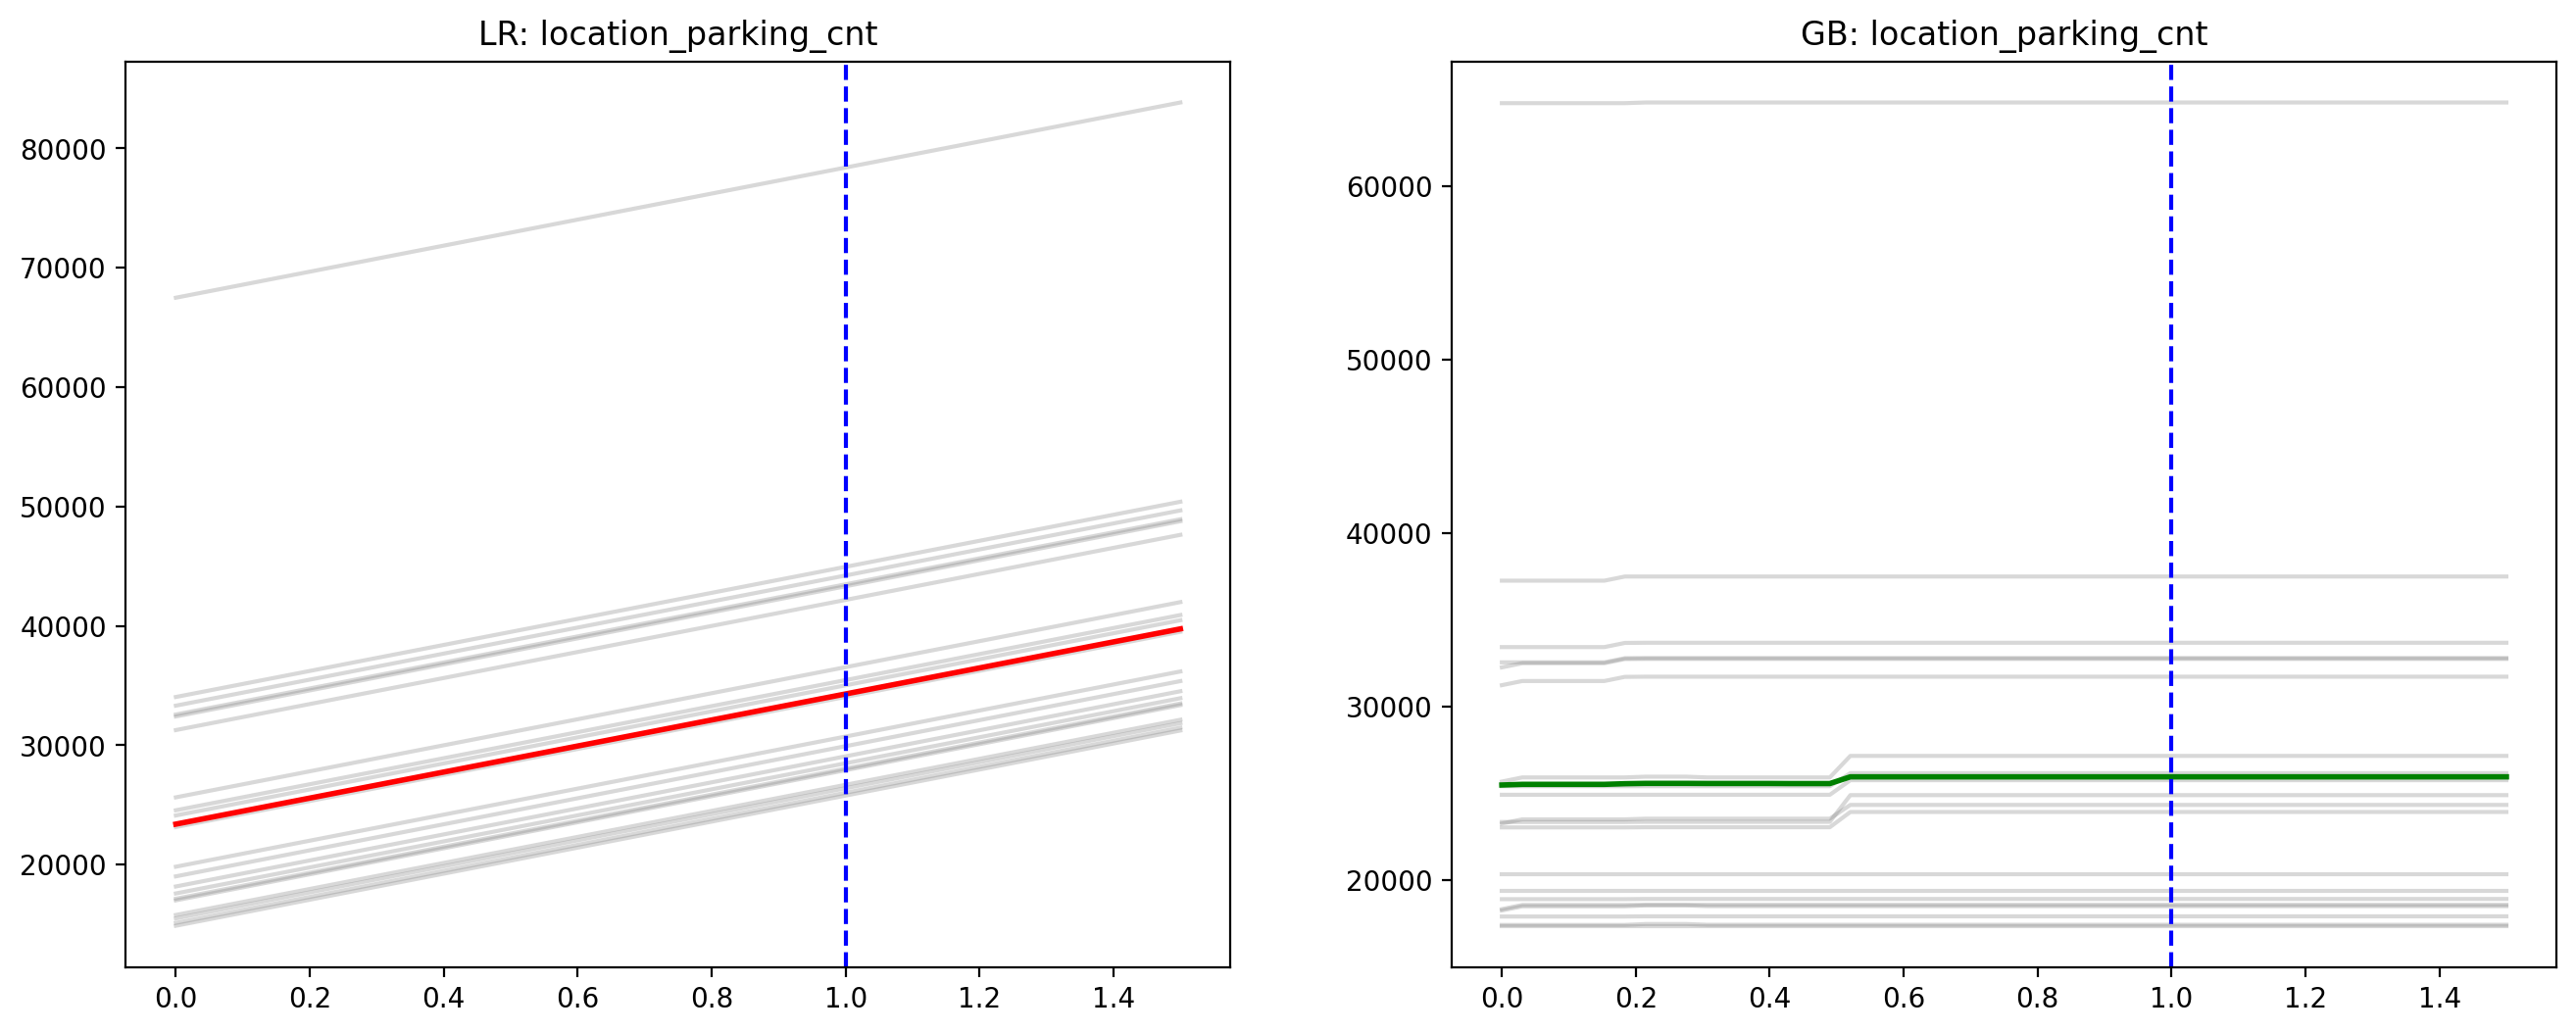

In [ ]:
feature_2 = 'location_parking_cnt'
grid_2 = np.linspace(0, 1.5, 50)

ice_lr_2, pdp_lr_2 = manual_ice_pdp(lr_model, X_subset, feature_2, grid_2)
ice_gb_2, pdp_gb_2 = manual_ice_pdp(gb_model, X_subset, feature_2, grid_2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i in range(20):
    ax[0].plot(grid_2, ice_lr_2[i], color='gray', alpha=0.3)
ax[0].plot(grid_2, pdp_lr_2, color='red', linewidth=2)
ax[0].axvline(1.0, color='blue', linestyle='--')
ax[0].set_title(f'LR: {feature_2}')

for i in range(20):
    ax[1].plot(grid_2, ice_gb_2[i], color='gray', alpha=0.3)
ax[1].plot(grid_2, pdp_gb_2, color='green', linewidth=2)
ax[1].axvline(1.0, color='blue', linestyle='--')
ax[1].set_title(f'GB: {feature_2}')

plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

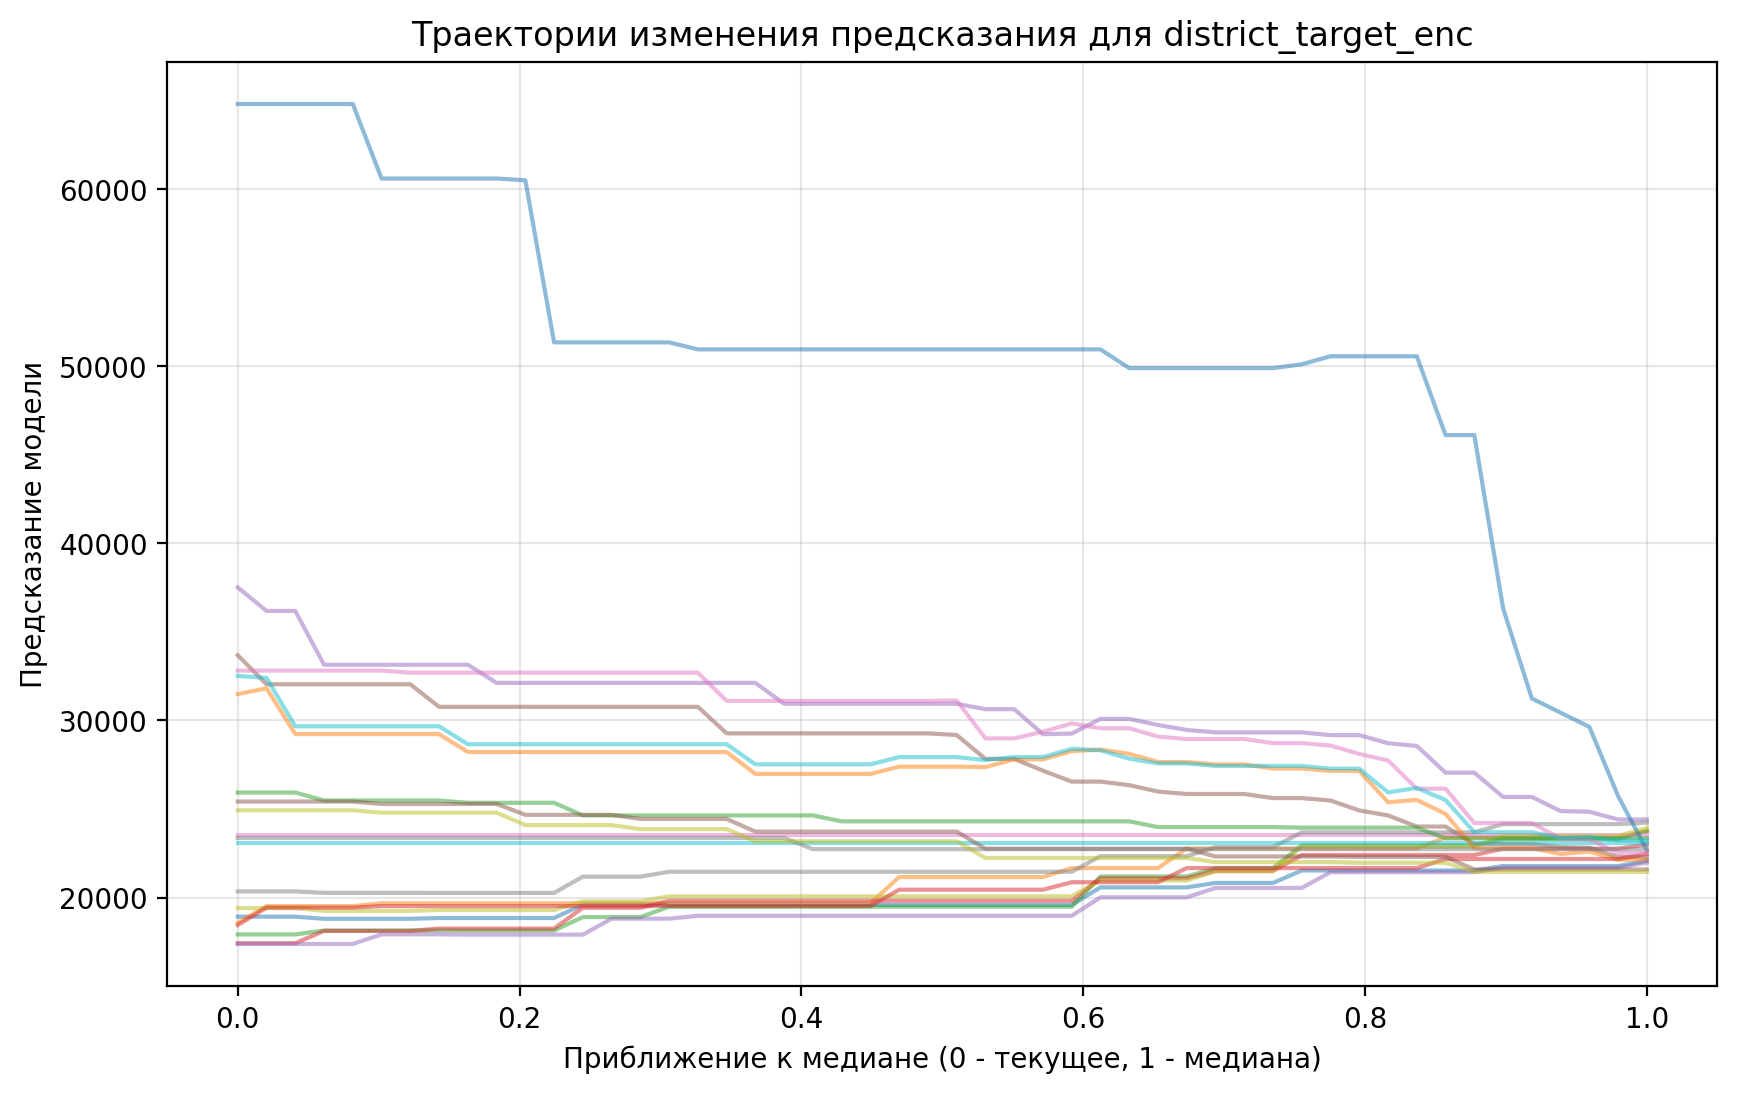

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_objects = 20
X_samples = X_te_mm.iloc[:n_objects].copy()
feature_j = 'district_target_enc'
base_value = X_tr_mm[feature_j].median()

n_steps = 50
steps = np.linspace(0, 1, n_steps)

plt.figure(figsize=(10, 6))

for i in range(n_objects):
    obj_orig = X_samples.iloc[[i]].copy()
    current_val = obj_orig[feature_j].values[0]
    
    predictions = []
    
    for alpha in steps:
        interpolated_val = current_val * (1 - alpha) + base_value * alpha
        obj_temp = obj_orig.copy()
        obj_temp[feature_j] = interpolated_val
        
        pred = gb_model.predict(obj_temp)[0]
        predictions.append(pred)
    
    plt.plot(steps, predictions, alpha=0.5)

plt.title(f'Траектории изменения предсказания для {feature_j}')
plt.xlabel('Приближение к медиане (0 - текущее, 1 - медиана)')
plt.ylabel('Предсказание модели')
plt.grid(True, alpha=0.3)
plt.show()

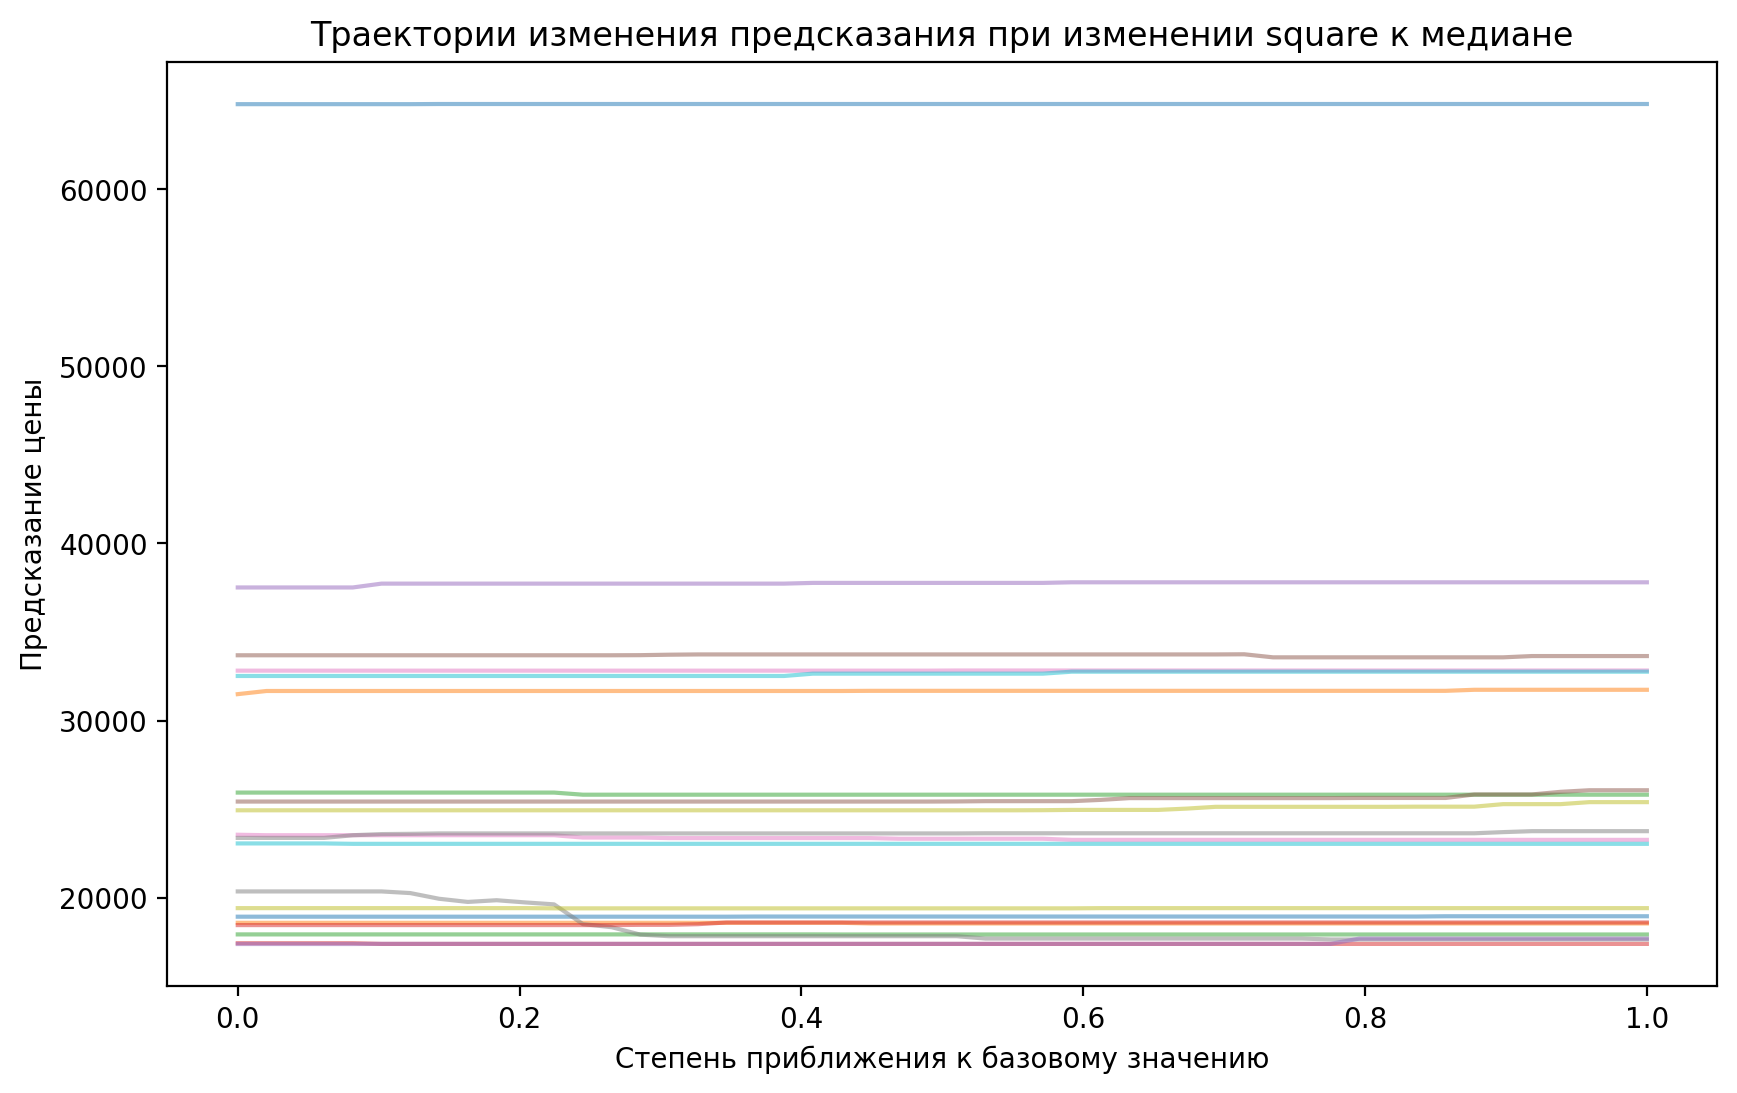

In [ ]:
feature_k = 'total_area' if 'total_area' in X_tr_mm.columns else 'square'
base_value_k = X_tr_mm[feature_k].median()

plt.figure(figsize=(10, 6))

for i in range(n_objects):
    obj = X_samples.iloc[i].copy()
    current_val = obj[feature_k]
    predictions = []
    
    for alpha in steps:
        interpolated_val = current_val * (1 - alpha) + base_value_k * alpha
        obj[feature_k] = interpolated_val
        pred = gb_model.predict(obj.values.reshape(1, -1))[0]
        predictions.append(pred)
    
    plt.plot(steps, predictions, alpha=0.5)

plt.title(f'Траектории изменения предсказания при изменении {feature_k} к медиане')
plt.xlabel('Степень приближения к базовому значению')
plt.ylabel('Предсказание цены')
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [16]:
%pip install PyALE -q

Note: you may need to restart the kernel to use updated packages.


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


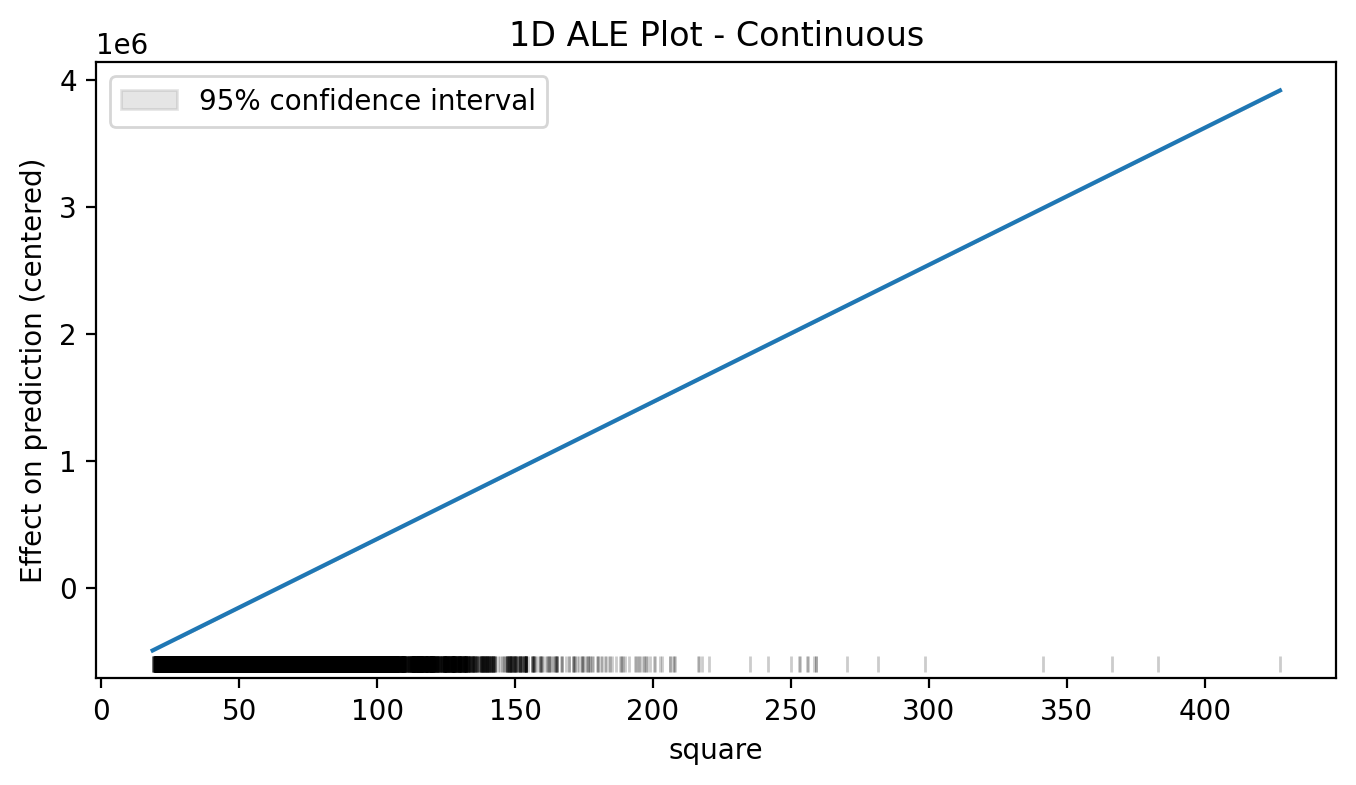

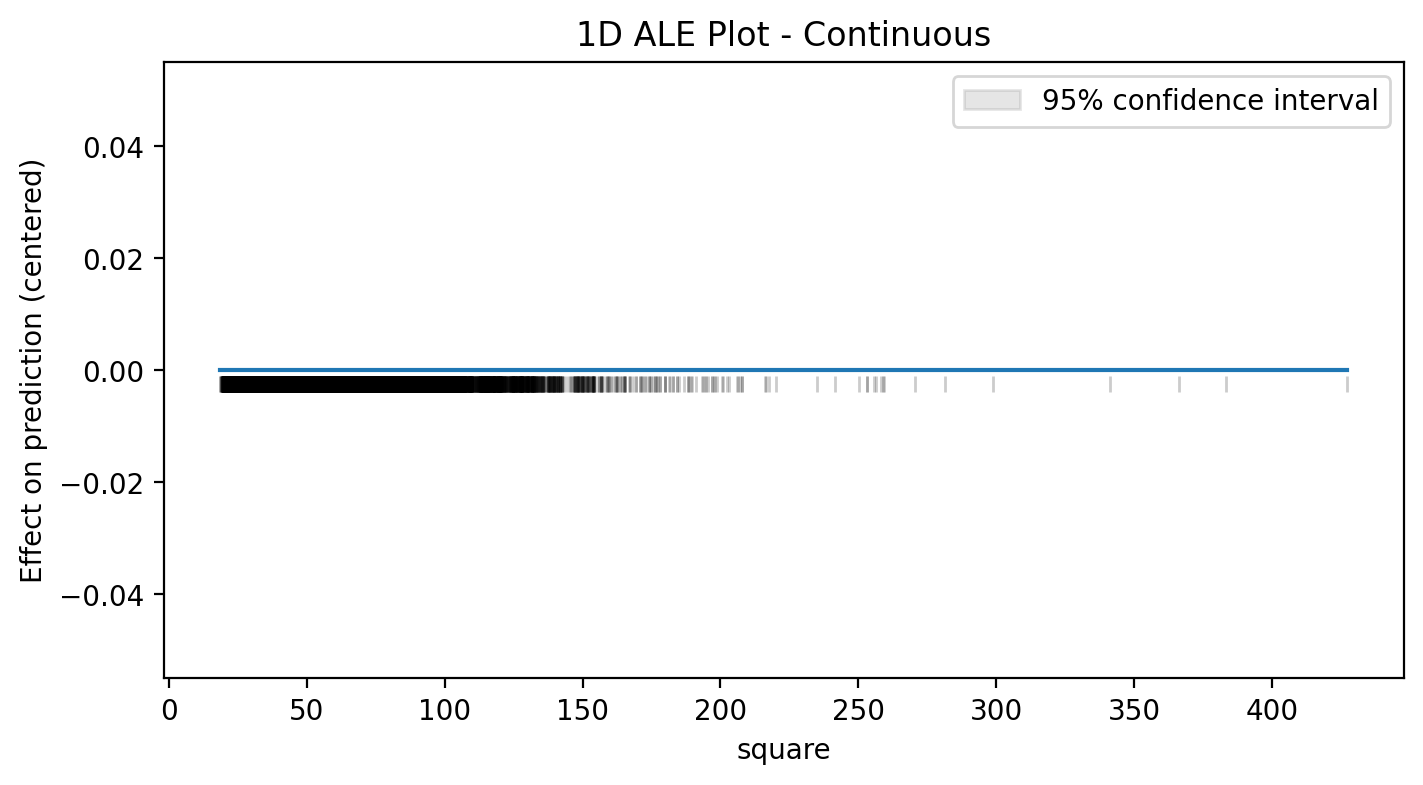

In [ ]:
from PyALE import ale

feature_ale = 'total_area' if 'total_area' in X_train.columns else 'square'

def predict_wrapper_lr(X_df):
    X_scaled = mm_scaler.transform(X_df)
    return lr_model.predict(X_scaled)

def predict_wrapper_gb(X_df):
    X_scaled = mm_scaler.transform(X_df)
    return gb_model.predict(X_scaled)

ale_lr = ale(
    X=X_train, 
    model=lr_model, # Если модель принимает исходные данные. Если нет - используй функцию-обертку
    feature=[feature_ale], 
    grid_size=20, 
    include_CI=True
)

ale_gb = ale(
    X=X_train, 
    model=gb_model, 
    feature=[feature_ale], 
    grid_size=20, 
    include_CI=True
)

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



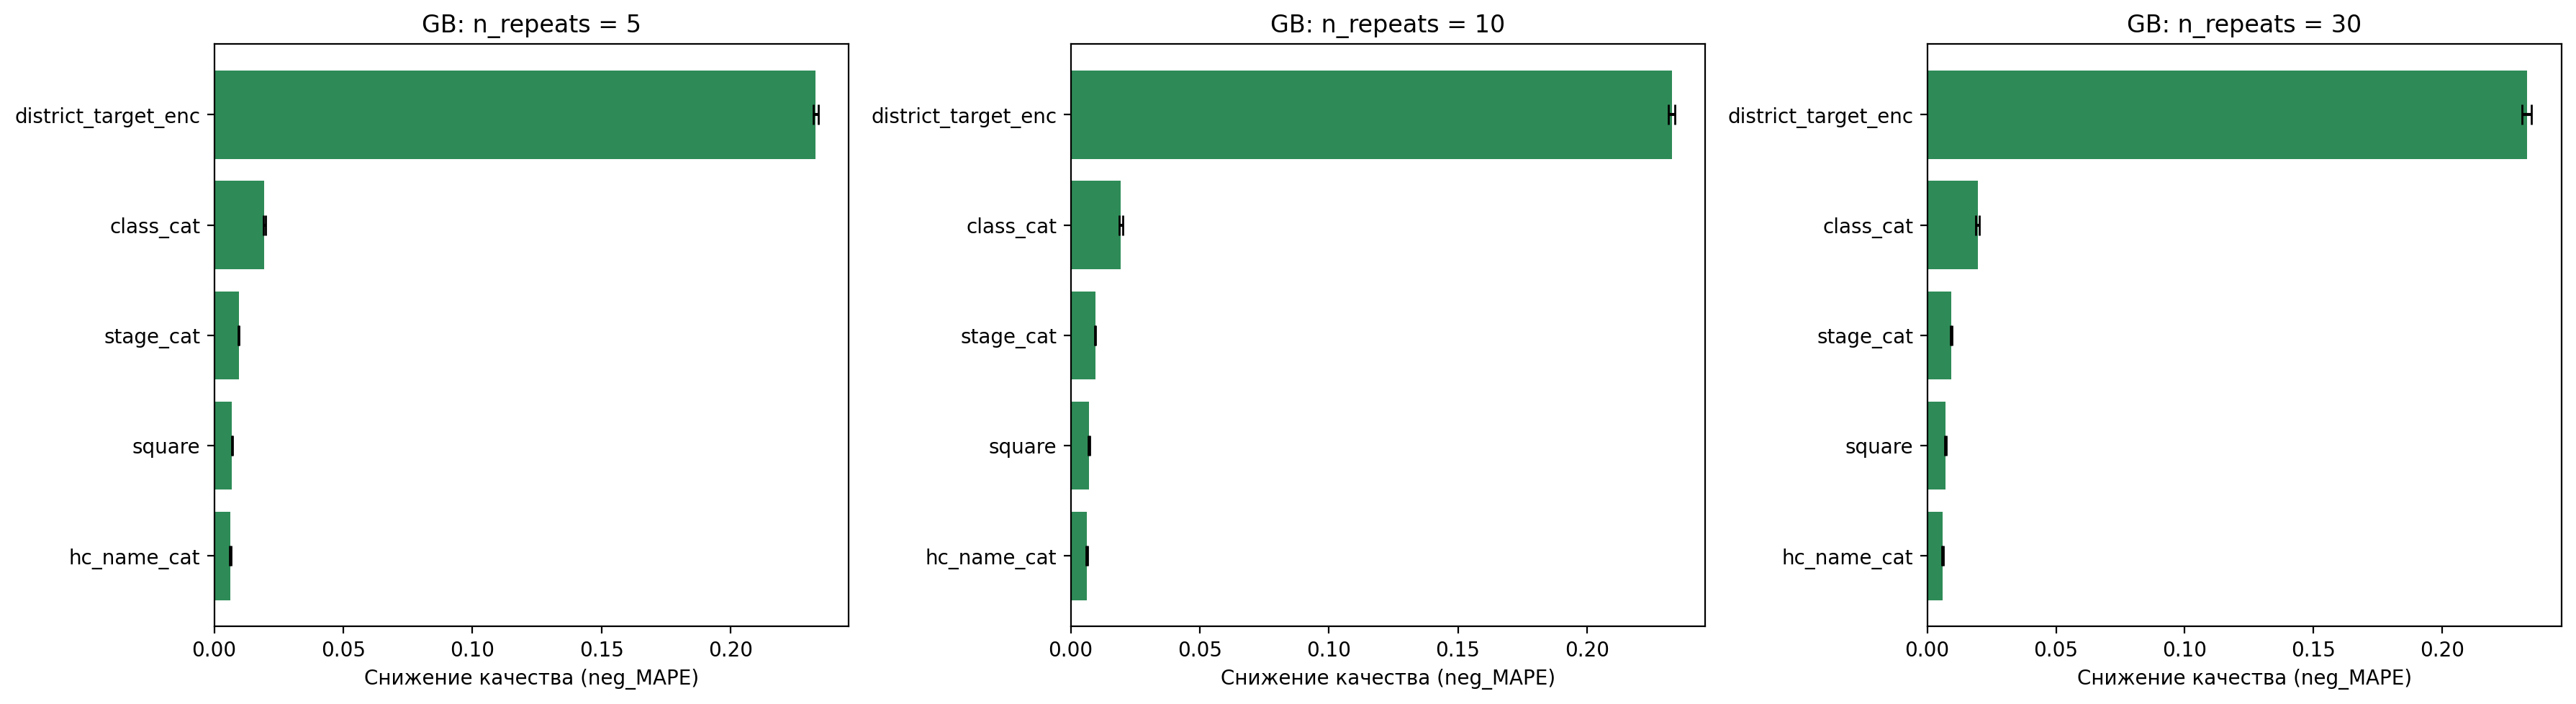

Стандартные отклонения (std) топ-5 признаков для Gradient Boosting:


,n_repeats=5,n_repeats=10,n_repeats=30
district_target_enc,0.001052,0.001211,0.001808
class_cat,0.000351,0.000690,0.000715
stage_cat,0.000167,0.000243,0.000331
square,0.000184,0.000214,0.000201
hc_name_cat,0.000320,0.000276,0.000264


In [ ]:
from sklearn.inspection import permutation_importance

repeats_list = [5, 10, 30]

gb_means = {}
gb_stds = {}
lr_means = {}
lr_stds = {}

for n in repeats_list:
    pi_gb = permutation_importance(gb_model, X_te_mm, y_test, n_repeats=n, 
                                   random_state=42, scoring='neg_mean_absolute_percentage_error')
    
    pi_lr = permutation_importance(lr_model, X_te_mm, y_test, n_repeats=n, 
                                   random_state=42, scoring='neg_mean_absolute_percentage_error')
    
    gb_means[n] = pi_gb.importances_mean
    gb_stds[n] = pi_gb.importances_std
    lr_means[n] = pi_lr.importances_mean
    lr_stds[n] = pi_lr.importances_std

top_idx = gb_means[30].argsort()[::-1][:5]
top_features = X_te_mm.columns[top_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, n in enumerate(repeats_list):
    means = gb_means[n][top_idx]
    stds = gb_stds[n][top_idx]
    
    axes[i].barh(top_features, means, xerr=stds, color='seagreen', capsize=5)
    axes[i].set_title(f'GB: n_repeats = {n}')
    axes[i].set_xlabel('Снижение качества (neg_MAPE)')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

stds_df = pd.DataFrame({f'n_repeats={n}': gb_stds[n][top_idx] for n in repeats_list}, index=top_features)
print("Стандартные отклонения (std) топ-5 признаков для Gradient Boosting:")
display(stds_df)

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

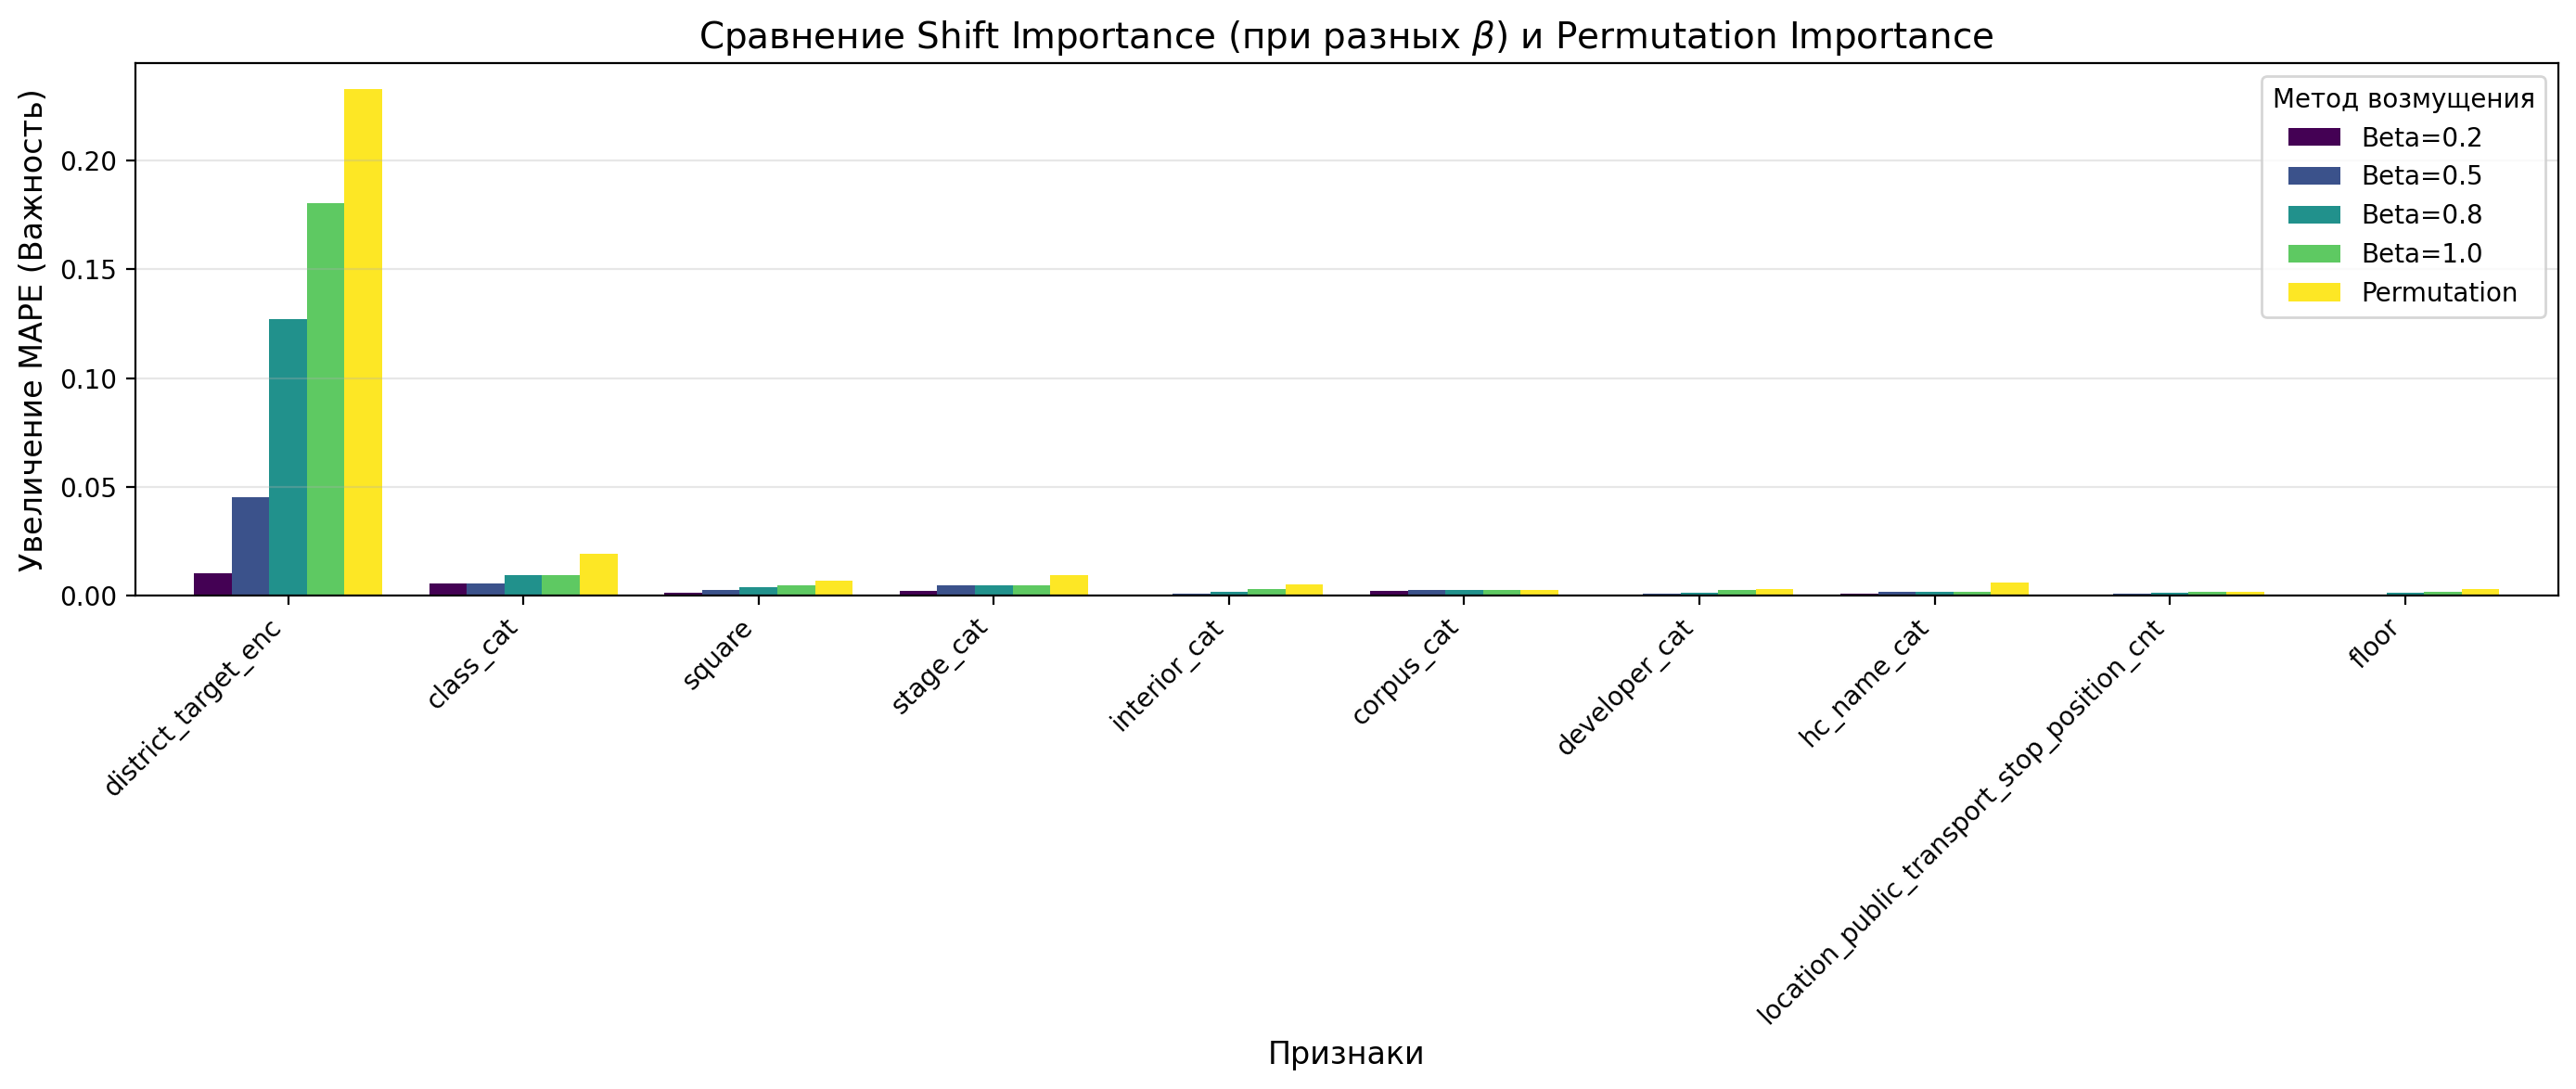

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_percentage_error

num_features = [col for col in X_tr_mm.columns if X_tr_mm[col].nunique() > 2]

baseline_mape = mean_absolute_percentage_error(y_test, gb_model.predict(X_te_mm))

def calculate_shift_importance(beta):
    importances = {}
    for col in num_features:
        X_temp = X_te_mm.copy()
        
        base_val = X_tr_mm[col].median()
        
        X_temp[col] = (1 - beta) * X_temp[col] + beta * base_val
        
        new_mape = mean_absolute_percentage_error(y_test, gb_model.predict(X_temp))
        
        importances[col] = new_mape - baseline_mape
        
    return pd.Series(importances)

betas = [0.2, 0.5, 0.8, 1.0]
shift_results = pd.DataFrame({f'Beta={b}': calculate_shift_importance(b) for b in betas})

pi = permutation_importance(gb_model, X_te_mm, y_test, n_repeats=10, 
                            random_state=42, scoring='neg_mean_absolute_percentage_error')
shift_results['Permutation'] = pd.Series(pi.importances_mean, index=X_te_mm.columns)[num_features]

top_10 = shift_results['Beta=1.0'].sort_values(ascending=False).head(10).index
plot_data = shift_results.loc[top_10]

plot_data.plot(kind='bar', figsize=(14, 6), colormap='viridis', width=0.8)
plt.title('Сравнение Shift Importance (при разных $\\beta$) и Permutation Importance', fontsize=14)
plt.ylabel('Увеличение MAPE (Важность)', fontsize=12)
plt.xlabel('Признаки', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Метод возмущения')
plt.tight_layout()
plt.show()

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



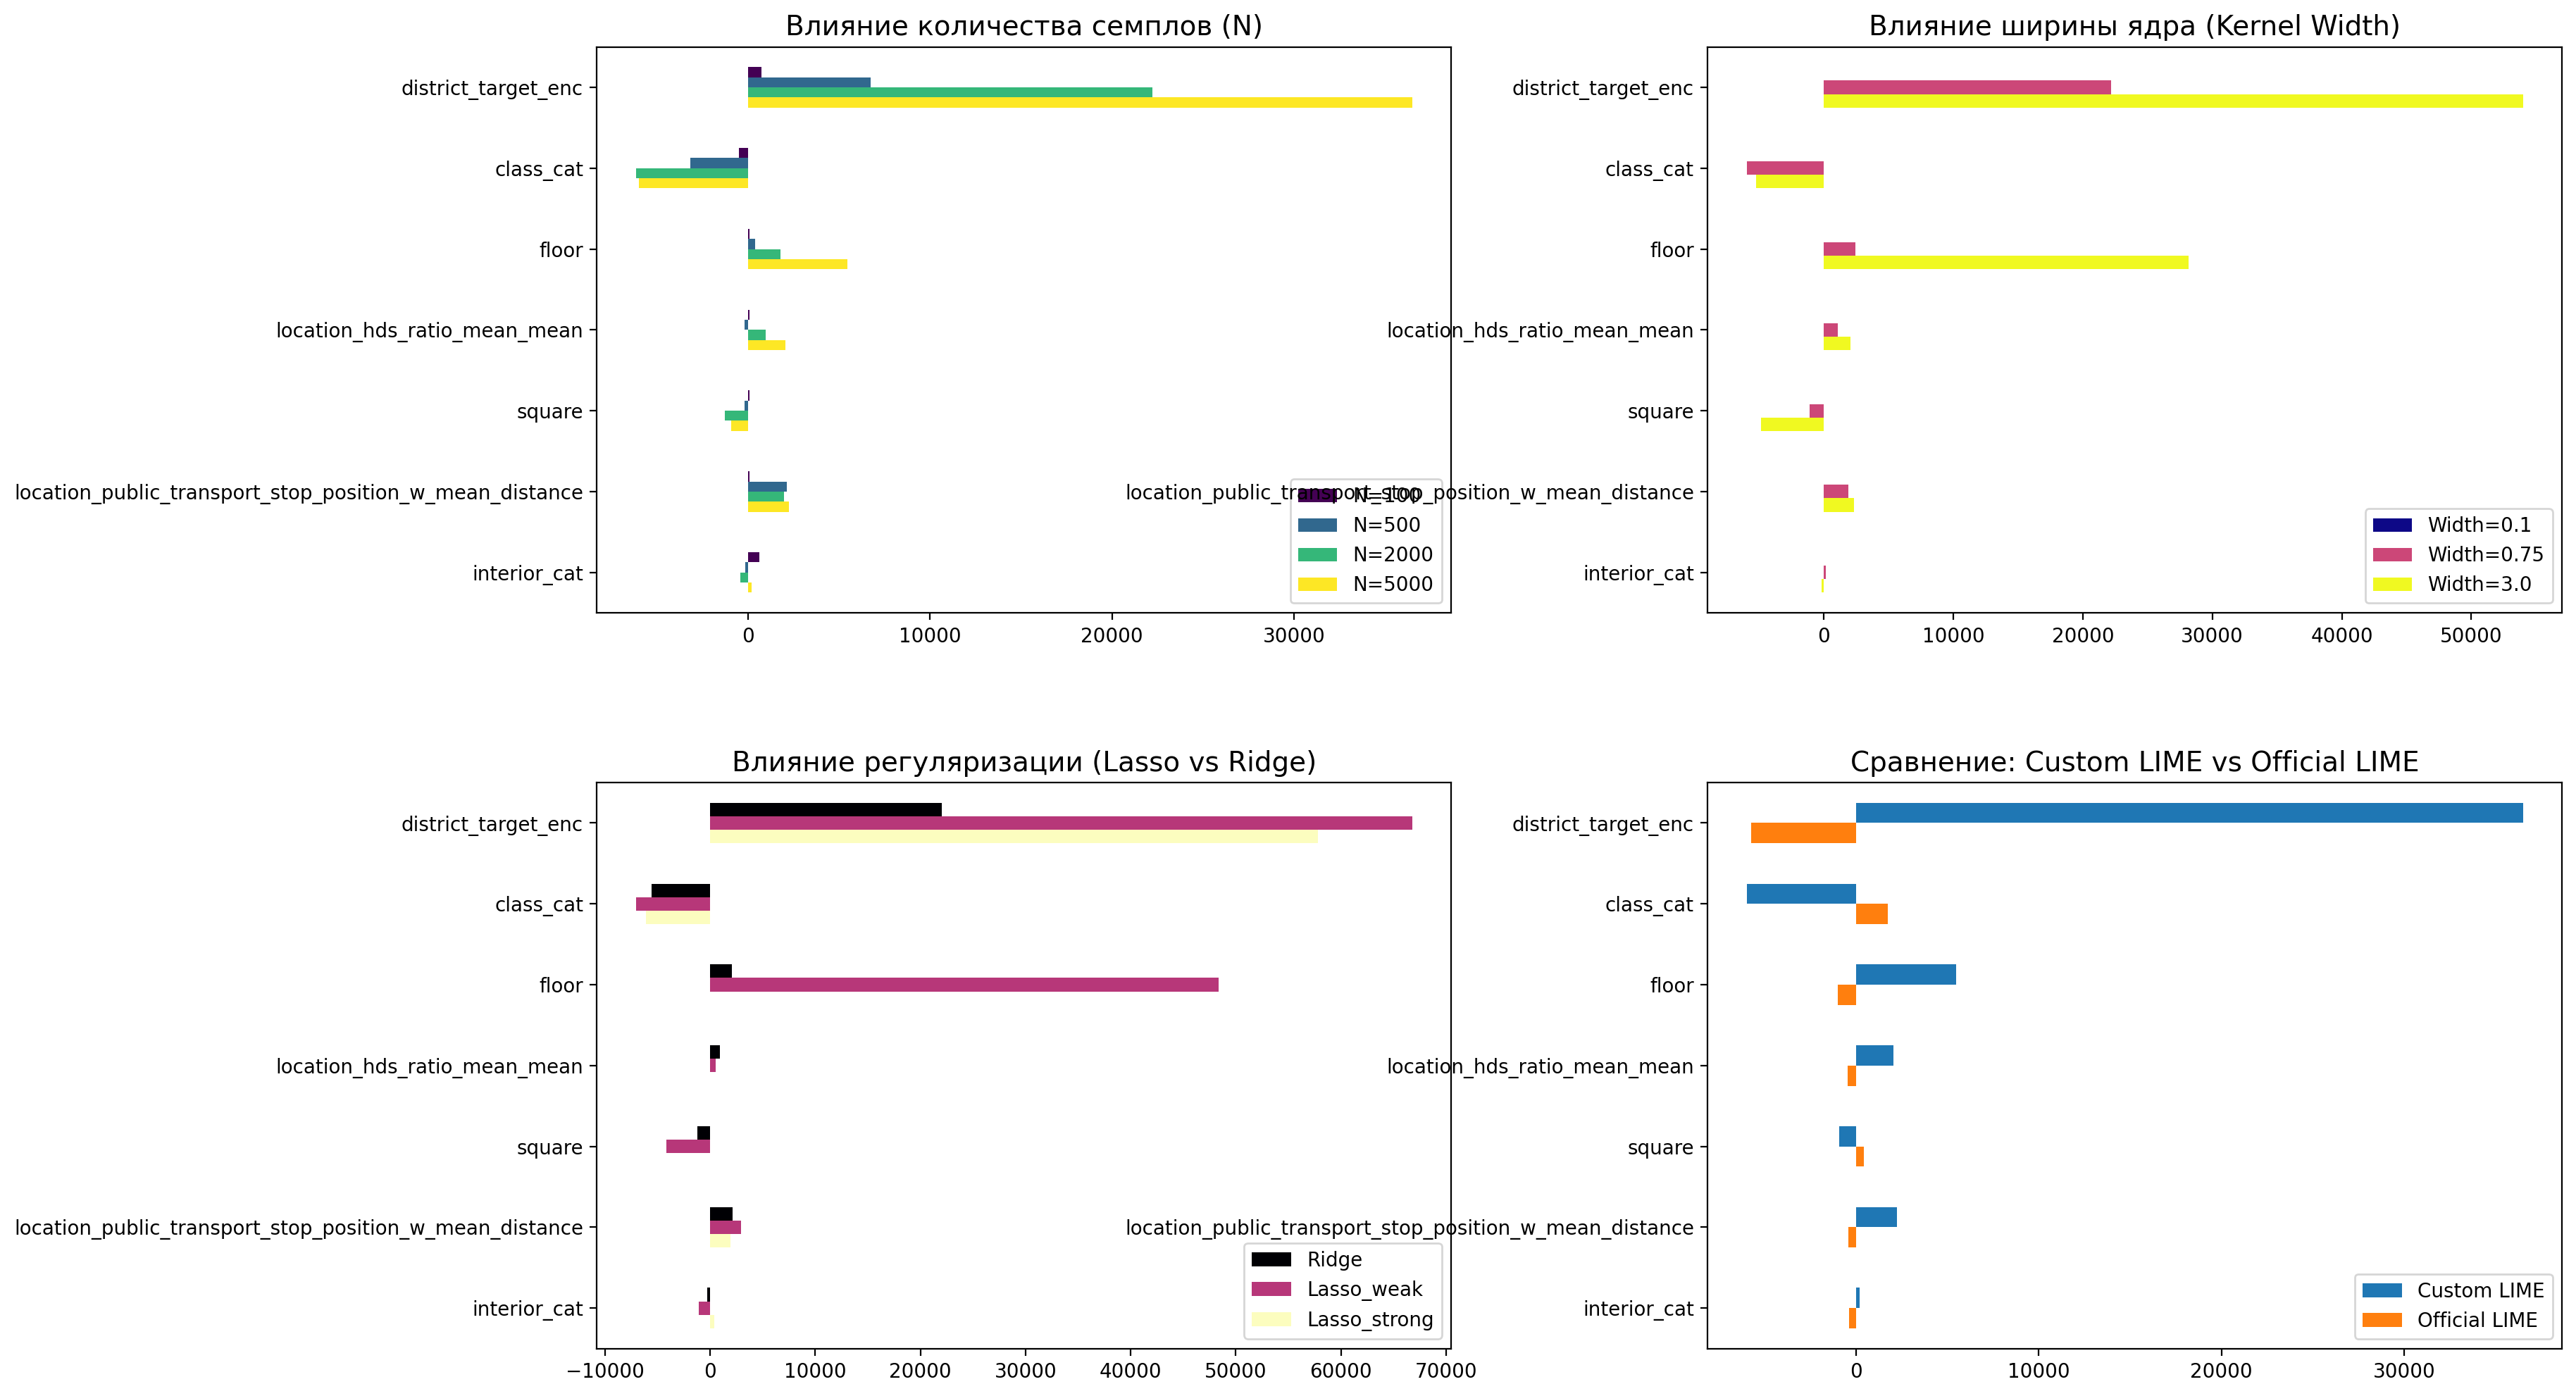

In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import pairwise_distances

class CustomLIME:
    def __init__(self, model, X_train, kernel_width=0.75):
        self.model = model
        self.std_devs = X_train.std(axis=0).values
        self.kernel_width = kernel_width
        self.feature_names = X_train.columns

    def _kernel_fn(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / (self.kernel_width ** 2)))

    def explain_instance(self, x_instance, num_samples=1000, reg_model='ridge', alpha=1.0):
        noise = np.random.normal(0, 1, size=(num_samples, len(x_instance))) * self.std_devs
        X_perturbed = x_instance.values.reshape(1, -1) + noise
        X_perturbed[0] = x_instance.values 
        
        X_df = pd.DataFrame(X_perturbed, columns=self.feature_names)
        y_perturbed = self.model.predict(X_df)
        
        distances = pairwise_distances(X_perturbed, x_instance.values.reshape(1, -1)).flatten()
        weights = self._kernel_fn(distances)
        
        if reg_model == 'ridge':
            local_model = Ridge(alpha=alpha, random_state=42)
        elif reg_model == 'lasso':
            local_model = Lasso(alpha=alpha, random_state=42)
        else:
            local_model = LinearRegression()
            
        local_model.fit(X_perturbed, y_perturbed, sample_weight=weights)
        return pd.Series(local_model.coef_, index=self.feature_names)

def test_custom_lime():
    dummy_model = LinearRegression()
    X_dummy = pd.DataFrame(np.random.rand(100, 3), columns=['f1', 'f2', 'f3'])
    y_dummy = X_dummy['f1'] * 2 + X_dummy['f2'] * 0.5
    dummy_model.fit(X_dummy, y_dummy)
    explainer = CustomLIME(dummy_model, X_dummy, kernel_width=1.0)
    coefs = explainer.explain_instance(X_dummy.iloc[0], num_samples=500, reg_model='ridge', alpha=0.001)
    
    assert np.allclose(coefs['f1'], 2.0, atol=0.1), "Тест f1 провален"
    assert np.allclose(coefs['f2'], 0.5, atol=0.1), "Тест f2 провален"
    assert np.allclose(coefs['f3'], 0.0, atol=0.1), "Тест f3 провален"

test_custom_lime()

instance_to_explain = X_te_mm.iloc[0]
explainer_base = CustomLIME(gb_model, X_tr_mm, kernel_width=0.75)

points_exp = [100, 500, 2000, 5000]
df_points = pd.DataFrame({f'N={n}': explainer_base.explain_instance(instance_to_explain, num_samples=n) for n in points_exp})

kernels_exp = [0.1, 0.75, 3.0]
df_kernels = pd.DataFrame({f'Width={k}': CustomLIME(gb_model, X_tr_mm, kernel_width=k).explain_instance(instance_to_explain, num_samples=2000) for k in kernels_exp})

df_reg = pd.DataFrame({
    'Ridge': explainer_base.explain_instance(instance_to_explain, num_samples=2000, reg_model='ridge', alpha=1.0),
    'Lasso_weak': explainer_base.explain_instance(instance_to_explain, num_samples=2000, reg_model='lasso', alpha=0.01),
    'Lasso_strong': explainer_base.explain_instance(instance_to_explain, num_samples=2000, reg_model='lasso', alpha=50.0)
})

official_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_tr_mm.values,
    feature_names=X_tr_mm.columns.tolist(),
    mode='regression',
    discretize_continuous=False, # Отключаем разбиение на бины для чистоты сравнения
    random_state=42
)

exp = official_explainer.explain_instance(
    data_row=instance_to_explain.values,
    predict_fn=gb_model.predict,
    num_features=len(X_tr_mm.columns)
)

official_weights = {X_tr_mm.columns[idx]: weight for idx, weight in exp.local_exp[0]}
official_series = pd.Series(official_weights)

df_compare = pd.DataFrame({
    'Custom LIME': df_points['N=5000'],
    'Official LIME': official_series
})

top_7_features = official_series.abs().sort_values(ascending=False).head(7).index

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

df_points.loc[top_7_features].plot(kind='barh', ax=axes[0, 0], colormap='viridis')
axes[0, 0].set_title('Влияние количества семплов (N)', fontsize=14)
axes[0, 0].invert_yaxis()

df_kernels.loc[top_7_features].plot(kind='barh', ax=axes[0, 1], colormap='plasma')
axes[0, 1].set_title('Влияние ширины ядра (Kernel Width)', fontsize=14)
axes[0, 1].invert_yaxis()

# График 3: Влияние регуляризации
df_reg.loc[top_7_features].plot(kind='barh', ax=axes[1, 0], colormap='magma')
axes[1, 0].set_title('Влияние регуляризации (Lasso vs Ridge)', fontsize=14)
axes[1, 0].invert_yaxis()

# График 4: Custom LIME vs Official LIME
df_compare.loc[top_7_features].plot(kind='barh', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'])
axes[1, 1].set_title('Сравнение: Custom LIME vs Official LIME', fontsize=14)
axes[1, 1].invert_yaxis()

plt.show()

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


In [22]:
%pip install shap -q

Note: you may need to restart the kernel to use updated packages.


=== SHAP Waterfall для Linear Regression (Объект 42) ===


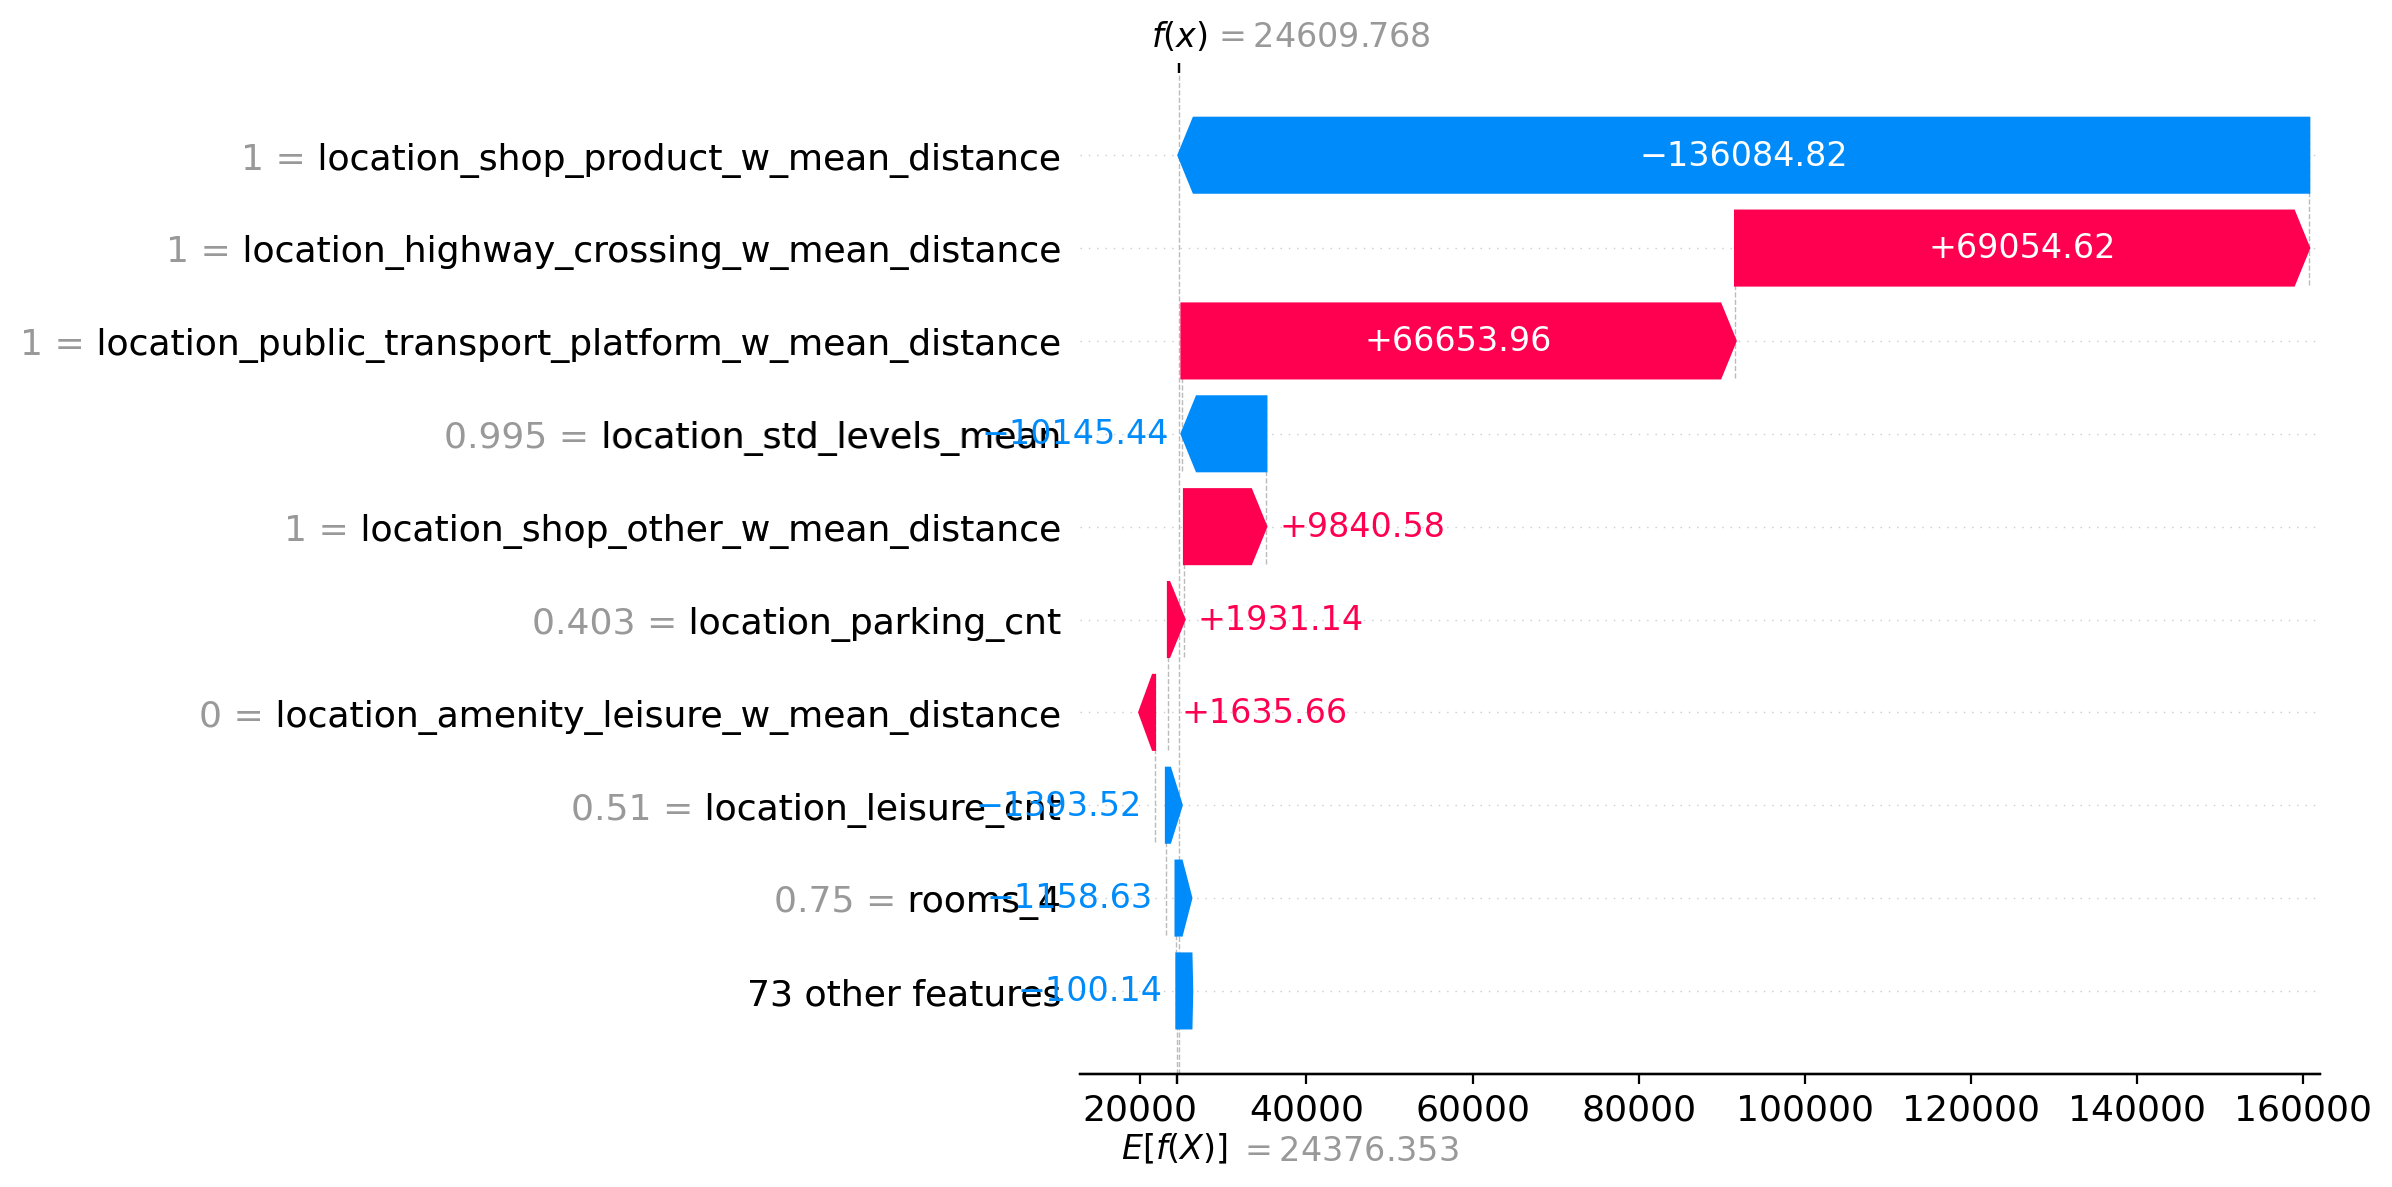


=== SHAP Waterfall для Gradient Boosting (Объект 42) ===


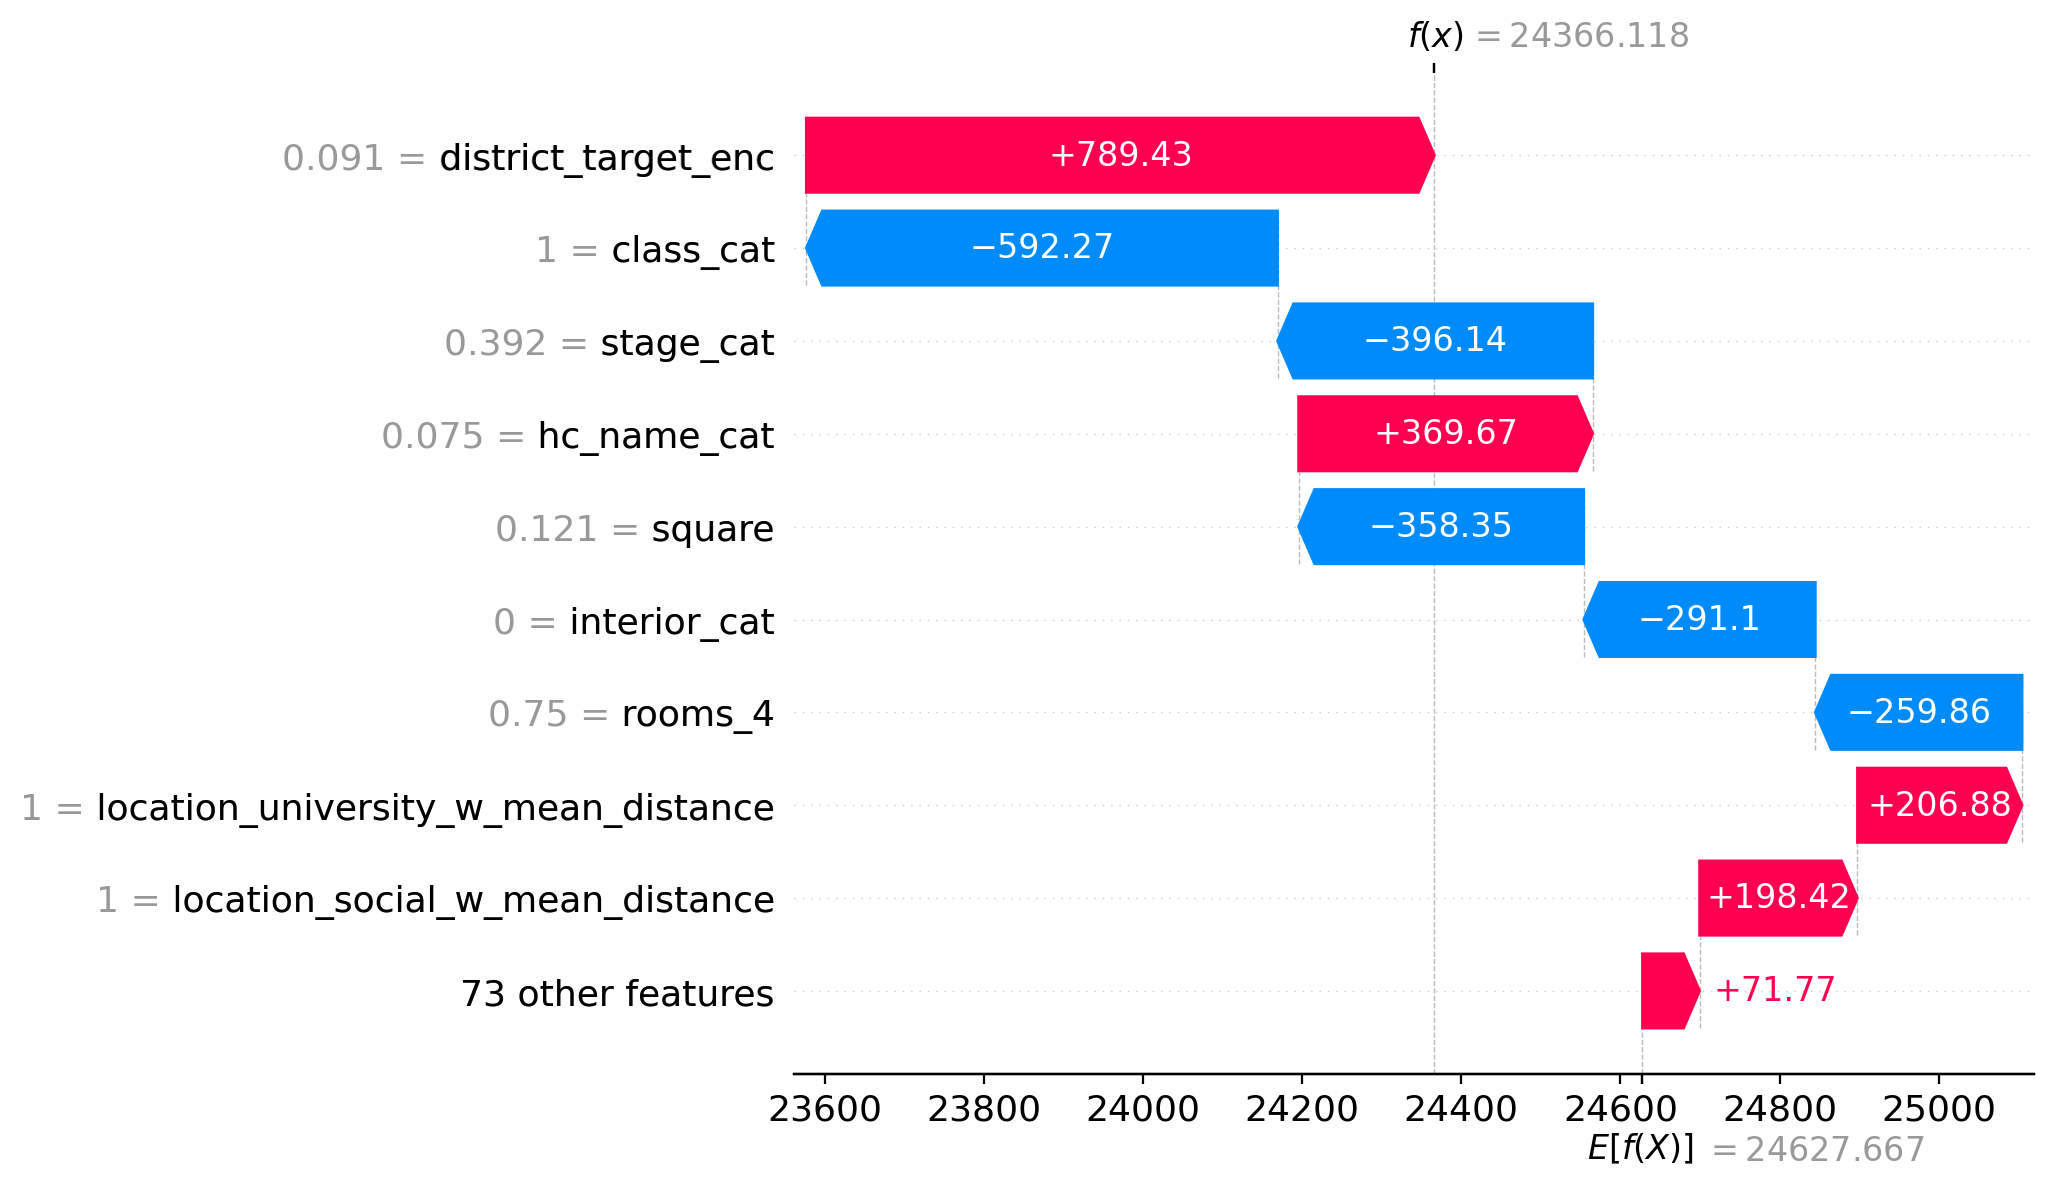


=== Проверка аддитивности SHAP для OHE ===
Суммарный вклад OHE-колонок ['region_name_cat_Область', 'region_name_cat_Пригород']: 4.0677
Вклад признака 'region_name_cat' при Label Encoding: 1.0082


In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor

shap.initjs()

my_index = 42
instance = X_te_mm.iloc[[my_index]]

explainer_lr = shap.LinearExplainer(lr_model, X_tr_mm)
shap_vals_lr = explainer_lr(instance)

explainer_gb = shap.TreeExplainer(gb_model)
shap_vals_gb = explainer_gb(instance)

print(f"=== SHAP Waterfall для Linear Regression (Объект {my_index}) ===")
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_vals_lr[0], max_display=10, show=True)

print(f"\n=== SHAP Waterfall для Gradient Boosting (Объект {my_index}) ===")
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_vals_gb[0], max_display=10, show=True)


print("\n=== Проверка аддитивности SHAP для OHE ===")

ohe_cols = [col for col in X_te_mm.columns if col.startswith('region_name_cat_')]
shap_values_dict = dict(zip(X_te_mm.columns, shap_vals_gb.values[0]))

sum_ohe_shap = sum([shap_values_dict[col] for col in ohe_cols if col in shap_values_dict])
print(f"Суммарный вклад OHE-колонок {ohe_cols}: {sum_ohe_shap:.4f}")

X_train_le = X_train.copy()
X_test_le = X_test.copy()

le = LabelEncoder()
X_train_le['region_name_cat_original'] = le.fit_transform(data.loc[X_train.index, 'region_name_cat'].astype(str))
X_test_le['region_name_cat_original'] = le.transform(data.loc[X_test.index, 'region_name_cat'].astype(str))

X_train_le = X_train_le.drop(columns=ohe_cols, errors='ignore')
X_test_le = X_test_le.drop(columns=ohe_cols, errors='ignore')

gb_model_le = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_le, y_train)
explainer_gb_le = shap.TreeExplainer(gb_model_le)
shap_vals_gb_le = explainer_gb_le(X_test_le.iloc[[my_index]])

shap_original_cat = shap_vals_gb_le.values[0][list(X_train_le.columns).index('region_name_cat_original')]
print(f"Вклад признака 'region_name_cat' при Label Encoding: {shap_original_cat:.4f}")